In [ ]:
!pip install -q kagglehub transformers librosa tqdm scikit-learn

In [ ]:
import kagglehub
import os, glob, warnings
import numpy as np
import pandas as pd
import librosa, librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import torch

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.utils import resample

warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
path = kagglehub.dataset_download(
    "kurianbenoy/malayalam-multispeaker-speech-data-set"
)
print("Dataset path:", path)

100%|██████████| 1.25G/1.25G [01:01<00:00, 21.8MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/kurianbenoy/malayalam-multispeaker-speech-data-set/versions/1


In [ ]:
f_df = pd.read_csv(f"{path}/line_index_female.tsv", sep="\t", header=None)
f_df.columns = ["path", "sentence"]
f_df["path"] += ".wav"
f_df["label"] = 1

m_df = pd.read_csv(f"{path}/line_index_male.tsv", sep="\t", header=None)
m_df.columns = ["path", "sentence"]
m_df["path"] += ".wav"
m_df["label"] = 0

df = pd.concat([f_df, m_df]).reset_index(drop=True)

In [ ]:
def get_speaker_id(fname):
    return fname.split("_")[1]

df["speaker"] = df["path"].apply(get_speaker_id)
print("Total speakers:", df["speaker"].nunique())

Total speakers: 42


In [ ]:
speakers = df["speaker"].unique()

train_spk, temp_spk = train_test_split(
    speakers, test_size=0.3, random_state=42
)
val_spk, test_spk = train_test_split(
    temp_spk, test_size=0.5, random_state=42
)

train_df = df[df.speaker.isin(train_spk)]
val_df   = df[df.speaker.isin(val_spk)]
test_df  = df[df.speaker.isin(test_spk)]

assert set(train_spk).isdisjoint(test_spk)
print("No speaker leakage")

No speaker leakage


In [ ]:
print("=== Speaker counts ===")
print("Total speakers :", len(speakers))
print("Train speakers :", len(train_spk))
print("Val speakers   :", len(val_spk))
print("Test speakers  :", len(test_spk))

=== Speaker counts ===
Total speakers : 42
Train speakers : 29
Val speakers   : 6
Test speakers  : 7


In [ ]:
print("\n=== Sample counts ===")
print("Train samples :", len(train_df))
print("Val samples   :", len(val_df))
print("Test samples  :", len(test_df))


=== Sample counts ===
Train samples : 2790
Val samples   : 671
Test samples  : 665


In [ ]:
def print_gender_dist(df, name):
    print(f"\n{name} gender distribution:")
    print(df["label"].value_counts().rename({0: "Male", 1: "Female"}))

print_gender_dist(train_df, "Train")
print_gender_dist(val_df, "Validation")
print_gender_dist(test_df, "Test")


Train gender distribution:
label
Female    1480
Male      1310
Name: count, dtype: int64

Validation gender distribution:
label
Male      445
Female    226
Name: count, dtype: int64

Test gender distribution:
label
Female    397
Male      268
Name: count, dtype: int64


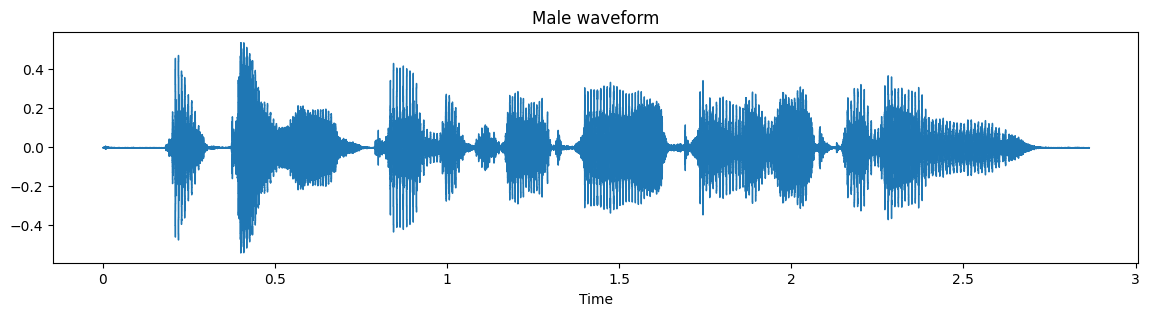

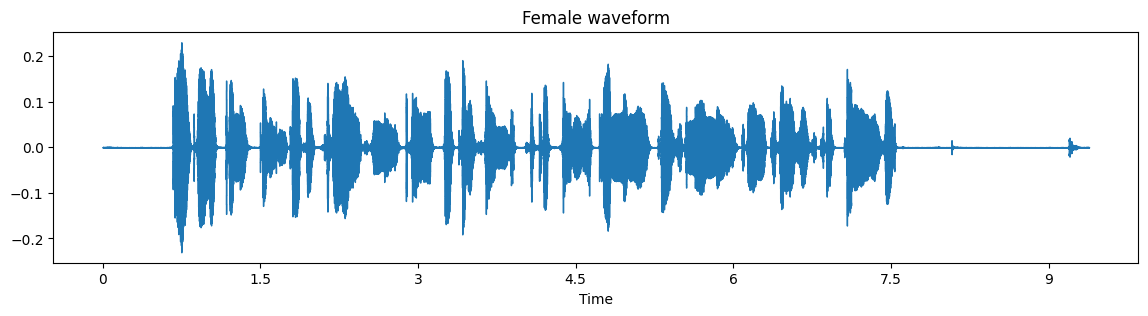

In [ ]:
male_file   = test_df[test_df.label==0].iloc[0]["path"]
female_file = test_df[test_df.label==1].iloc[0]["path"]

m_wav,_ = librosa.load(f"{path}/ml_in_male/{male_file}", sr=16000)
f_wav,_ = librosa.load(f"{path}/ml_in_female/{female_file}", sr=16000)

plt.figure(figsize=(14,3))
librosa.display.waveshow(m_wav, sr=16000)
plt.title("Male waveform")
plt.show()

plt.figure(figsize=(14,3))
librosa.display.waveshow(f_wav, sr=16000)
plt.title("Female waveform")
plt.show()

ipd.display(ipd.Audio(m_wav, rate=16000))
ipd.display(ipd.Audio(f_wav, rate=16000))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from tqdm import tqdm
import numpy as np

def extract_mfcc(fp):
    y,_ = librosa.load(fp, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=16000, n_mfcc=40)
    d1 = librosa.feature.delta(mfcc)
    d2 = librosa.feature.delta(mfcc, order=2)
    return np.vstack([mfcc, d1, d2]).mean(axis=1)

def build_mfcc(df, split_name=""):
    X, y = [], []
    for _, r in tqdm(df.iterrows(), total=len(df), desc=f"MFCC {split_name}"):
        folder = "ml_in_female" if r.label == 1 else "ml_in_male"
        X.append(extract_mfcc(f"{path}/{folder}/{r.path}"))
        y.append(r.label)
    return np.array(X), np.array(y)

# ---------- Build features ----------
Xtr_mfcc, ytr = build_mfcc(train_df, "Train")
Xva_mfcc, yva = build_mfcc(val_df,   "Val")
Xte_mfcc, yte = build_mfcc(test_df,  "Test")

# ---------- Validation-based selection ----------
Cs = [0.01, 0.1, 1, 10]
val_acc = []

for C in Cs:
    clf = LogisticRegression(C=C, max_iter=2000)
    clf.fit(Xtr_mfcc, ytr)
    acc = accuracy_score(yva, clf.predict(Xva_mfcc))
    val_acc.append(acc)

best_C = Cs[np.argmax(val_acc)]
print("Best C (from validation):", best_C)

# ---------- Final training & testing ----------
mfcc_clf = LogisticRegression(C=best_C, max_iter=2000)
mfcc_clf.fit(Xtr_mfcc, ytr)

mfcc_pred = mfcc_clf.predict(Xte_mfcc)
mfcc_prob = mfcc_clf.predict_proba(Xte_mfcc)[:, 1]

mfcc_acc = accuracy_score(yte, mfcc_pred)
mfcc_f1  = f1_score(yte, mfcc_pred)
mfcc_auc = roc_auc_score(yte, mfcc_prob)

print("MFCC Test Accuracy:", mfcc_acc)
print("MFCC Test F1:", mfcc_f1)
print("MFCC Test AUC:", mfcc_auc)

MFCC Test: 100%|██████████| 665/665 [00:20<00:00, 31.67it/s]


Best C (from validation): 0.01
MFCC Test Accuracy: 0.8015037593984963
MFCC Test F1: 0.857451403887689
MFCC Test AUC: 0.9990883115906614


In [ ]:
CACHE = "./ssl_cache"
os.makedirs(CACHE, exist_ok=True)

In [ ]:
from transformers import Wav2Vec2Processor, Wav2Vec2Model

w2v_proc = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
w2v_model = Wav2Vec2Model.from_pretrained(
    "facebook/wav2vec2-base",
    output_hidden_states=True
).to(device).eval()

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

In [ ]:
from tqdm import tqdm
import numpy as np
import os
import librosa
import torch

def extract_ssl(df, name, split, processor, model):
    emb_f = f"{CACHE}/{name}_{split}.npy"

    if os.path.exists(emb_f):
        print(f"Loaded cached {name} embeddings ({split})")
        return np.load(emb_f)

    feats = []

    # ---- Progress bar ----
    for _, r in tqdm(
        df.iterrows(),
        total=len(df),
        desc=f"{name.upper()} | {split}"
    ):
        folder = "ml_in_female" if r.label == 1 else "ml_in_male"
        wav, _ = librosa.load(f"{path}/{folder}/{r.path}", sr=16000)

        inp = processor(
            wav,
            sampling_rate=16000,
            return_tensors="pt"
        )

        with torch.no_grad():
            hs = model(**inp.to(device)).hidden_states  # tuple (L, T, D)

        # Mean pooling for each layer
        feats.append([
            h.squeeze(0).mean(dim=0).cpu().numpy()
            for h in hs
        ])

    arr = np.array(feats)  # (N, layers, dim)
    np.save(emb_f, arr)

    return arr

In [ ]:
Xtr_w2v = extract_ssl(train_df, "w2v", "train", w2v_proc, w2v_model)
Xva_w2v = extract_ssl(val_df,   "w2v", "val",   w2v_proc, w2v_model)
Xte_w2v = extract_ssl(test_df,  "w2v", "test",  w2v_proc, w2v_model)

W2V | train:   0%|          | 1/2790 [00:00<43:51,  1.06it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

W2V | train: 100%|██████████| 2790/2790 [01:34<00:00, 29.40it/s]
W2V | val: 100%|██████████| 671/671 [00:22<00:00, 29.75it/s]
W2V | test: 100%|██████████| 665/665 [00:20<00:00, 32.61it/s]


In [ ]:
from transformers import HubertModel

hubert_model = HubertModel.from_pretrained(
    "facebook/hubert-base-ls960",
    output_hidden_states=True
).to(device).eval()

Xtr_hubert = extract_ssl(train_df, "hubert", "train", w2v_proc, hubert_model)
Xva_hubert = extract_ssl(val_df,   "hubert", "val",   w2v_proc, hubert_model)
Xte_hubert = extract_ssl(test_df,  "hubert", "test",  w2v_proc, hubert_model)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

HUBERT | train:   1%|          | 34/2790 [00:01<01:33, 29.37it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

HUBERT | train: 100%|██████████| 2790/2790 [01:35<00:00, 29.10it/s]
HUBERT | val: 100%|██████████| 671/671 [00:22<00:00, 30.02it/s]
HUBERT | test: 100%|██████████| 665/665 [00:20<00:00, 31.98it/s]


In [ ]:
from transformers import WhisperProcessor, WhisperModel

wh_proc = WhisperProcessor.from_pretrained("openai/whisper-small")
wh_model = WhisperModel.from_pretrained(
    "openai/whisper-small",
    output_hidden_states=True
).encoder.to(device).eval()

preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

In [ ]:
from tqdm import tqdm
import numpy as np
import os
import librosa
import torch

def extract_whisper(df, name, split):
    emb_f = f"{CACHE}/{name}_{split}.npy"

    if os.path.exists(emb_f):
        print(f"Loaded cached Whisper embeddings ({split})")
        return np.load(emb_f)

    feats = []

    # ---- Progress bar ----
    for _, r in tqdm(
        df.iterrows(),
        total=len(df),
        desc=f"WHISPER | {split}"
    ):
        folder = "ml_in_female" if r.label == 1 else "ml_in_male"
        wav, _ = librosa.load(f"{path}/{folder}/{r.path}", sr=16000)

        inp = wh_proc(
            wav,
            sampling_rate=16000,
            return_tensors="pt"
        ).input_features

        with torch.no_grad():
            hs = wh_model(inp.to(device)).hidden_states  # tuple (layers)

        # Mean pooling per layer
        feats.append([
            h.squeeze(0).mean(dim=0).cpu().numpy()
            for h in hs
        ])

    arr = np.array(feats)  # (N, layers, dim)
    np.save(emb_f, arr)

    return arr
Xtr_wh = extract_whisper(train_df, "whisper", "train")
Xva_wh = extract_whisper(val_df,   "whisper", "val")
Xte_wh = extract_whisper(test_df,  "whisper", "test")

WHISPER | train: 100%|██████████| 2790/2790 [06:30<00:00,  7.14it/s]
WHISPER | val: 100%|██████████| 671/671 [01:26<00:00,  7.72it/s]
WHISPER | test: 100%|██████████| 665/665 [01:24<00:00,  7.83it/s]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def layer_acc_val(Xtr, ytr, Xva, yva):
    acc = []
    for l in range(Xtr.shape[1]):
        clf = LogisticRegression(max_iter=2000)
        clf.fit(Xtr[:, l, :], ytr)
        acc.append(accuracy_score(yva, clf.predict(Xva[:, l, :])))
    return acc

In [ ]:
acc_w2v_val    = layer_acc_val(Xtr_w2v, ytr, Xva_w2v, yva)
acc_hubert_val = layer_acc_val(Xtr_hubert, ytr, Xva_hubert, yva)
acc_wh_val     = layer_acc_val(Xtr_wh, ytr, Xva_wh, yva)

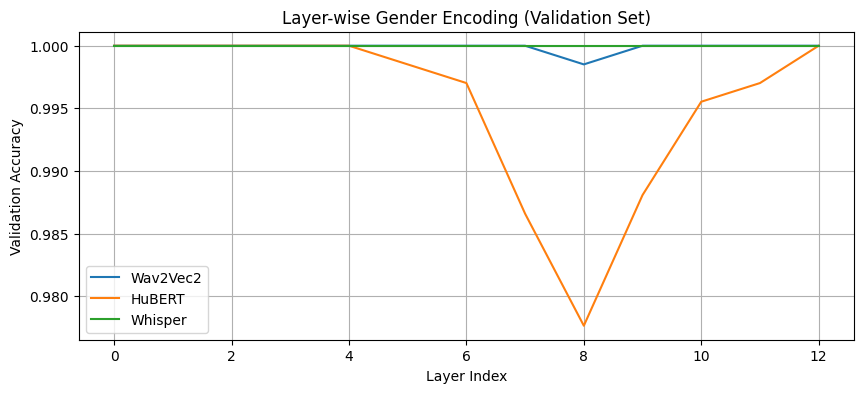

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(acc_w2v_val, label="Wav2Vec2")
plt.plot(acc_hubert_val, label="HuBERT")
plt.plot(acc_wh_val, label="Whisper")
plt.xlabel("Layer Index")
plt.ylabel("Validation Accuracy")
plt.title("Layer-wise Gender Encoding (Validation Set)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
best_w2v_layer    = np.argmax(acc_w2v_val)
best_hubert_layer = np.argmax(acc_hubert_val)
best_wh_layer     = np.argmax(acc_wh_val)

print("Best W2V layer   :", best_w2v_layer)
print("Best HuBERT layer:", best_hubert_layer)
print("Best Whisper layer:", best_wh_layer)

Best W2V layer   : 0
Best HuBERT layer: 0
Best Whisper layer: 0


In [ ]:
def test_eval(Xtr, ytr, Xte, yte, layer):
    clf = LogisticRegression(max_iter=2000)
    clf.fit(Xtr[:, layer, :], ytr)
    pred = clf.predict(Xte[:, layer, :])
    return accuracy_score(yte, pred)

In [ ]:
acc_w2v_test    = test_eval(Xtr_w2v, ytr, Xte_w2v, yte, best_w2v_layer)
acc_hubert_test = test_eval(Xtr_hubert, ytr, Xte_hubert, yte, best_hubert_layer)
acc_wh_test     = test_eval(Xtr_wh, ytr, Xte_wh, yte, best_wh_layer)

print("Test Acc W2V   :", acc_w2v_test)
print("Test Acc HuBERT:", acc_hubert_test)
print("Test Acc Whisper:", acc_wh_test)

Test Acc W2V   : 0.8601503759398497
Test Acc HuBERT: 0.8842105263157894
Test Acc Whisper: 0.8330827067669173


In [ ]:
def best_acc(acc): return max(acc)

results = {
    "MFCC": mfcc_acc,
    "Wav2Vec2": acc_w2v_test,
    "HuBERT": acc_hubert_test,
    "Whisper": acc_wh_test
}

results_df = pd.DataFrame.from_dict(
    results, orient="index", columns=["Test Accuracy"]
)

results_df

,Test Accuracy
MFCC,0.801504
Wav2Vec2,0.860150
HuBERT,0.884211
Whisper,0.833083


In [ ]:
layer_info = pd.DataFrame({
    "Model": ["Wav2Vec2", "HuBERT", "Whisper"],
    "Selected Layer (Val)": [
        best_w2v_layer,
        best_hubert_layer,
        best_wh_layer
    ]
})

layer_info

,Model,Selected Layer (Val)
0,Wav2Vec2,0
1,HuBERT,0
2,Whisper,0


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.utils import resample
import numpy as np

def bootstrap_ci(y_true, y_pred, n=1000):
    idx = np.arange(len(y_true))
    scores = []

    for _ in range(n):
        sample_idx = resample(idx)
        scores.append(
            accuracy_score(
                y_true[sample_idx],
                y_pred[sample_idx]
            )
        )

    return np.mean(scores), np.percentile(scores, [2.5, 97.5])


In [ ]:
# Wav2Vec2 predictions
clf = LogisticRegression(max_iter=2000)
clf.fit(Xtr_w2v[:, best_w2v_layer, :], ytr)
w2v_pred = clf.predict(Xte_w2v[:, best_w2v_layer, :])

# HuBERT predictions
clf = LogisticRegression(max_iter=2000)
clf.fit(Xtr_hubert[:, best_hubert_layer, :], ytr)
hubert_pred = clf.predict(Xte_hubert[:, best_hubert_layer, :])

# Whisper predictions
clf = LogisticRegression(max_iter=2000)
clf.fit(Xtr_wh[:, best_wh_layer, :], ytr)
whisper_pred = clf.predict(Xte_wh[:, best_wh_layer, :])


In [ ]:
mfcc_ci   = bootstrap_ci(yte, mfcc_pred)
w2v_ci    = bootstrap_ci(yte, w2v_pred)
hubert_ci = bootstrap_ci(yte, hubert_pred)
wh_ci     = bootstrap_ci(yte, whisper_pred)

print("MFCC CI   :", mfcc_ci)
print("Wav2Vec2 CI:", w2v_ci)
print("HuBERT CI :", hubert_ci)
print("Whisper CI:", wh_ci)


MFCC CI   : (np.float64(0.8012135338345865), array([0.76992481, 0.83007519]))
Wav2Vec2 CI: (np.float64(0.8599413533834586), array([0.83157895, 0.88571429]))
HuBERT CI : (np.float64(0.8845654135338346), array([0.86165414, 0.90827068]))
Whisper CI: (np.float64(0.8336766917293232), array([0.80447368, 0.86169173]))


In [ ]:
mfcc_correct   = (mfcc_pred   == yte).astype(int)
w2v_correct    = (w2v_pred    == yte).astype(int)
hubert_correct = (hubert_pred == yte).astype(int)
wh_correct     = (whisper_pred == yte).astype(int)


In [ ]:
def cohens_d(a, b):
    return (np.mean(a) - np.mean(b)) / np.sqrt(
        (np.var(a, ddof=1) + np.var(b, ddof=1)) / 2
    )


In [ ]:
d_w2v_vs_mfcc    = cohens_d(w2v_correct, mfcc_correct)
d_hubert_vs_mfcc = cohens_d(hubert_correct, mfcc_correct)
d_wh_vs_mfcc     = cohens_d(wh_correct, mfcc_correct)

print("Cohen's d (W2V vs MFCC):", d_w2v_vs_mfcc)
print("Cohen's d (HuBERT vs MFCC):", d_hubert_vs_mfcc)
print("Cohen's d (Whisper vs MFCC):", d_wh_vs_mfcc)


Cohen's d (W2V vs MFCC): 0.15679345567364245
Cohen's d (HuBERT vs MFCC): 0.22856613559749742
Cohen's d (Whisper vs MFCC): 0.08172735476775378


In [ ]:
final_results = pd.DataFrame({
    "Model": ["MFCC", "Wav2Vec2", "HuBERT", "Whisper"],
    "Test Accuracy": [
        mfcc_acc,
        acc_w2v_test,
        acc_hubert_test,
        acc_wh_test
    ],
    "95% CI Lower": [
        mfcc_ci[1][0],
        w2v_ci[1][0],
        hubert_ci[1][0],
        wh_ci[1][0]
    ],
    "95% CI Upper": [
        mfcc_ci[1][1],
        w2v_ci[1][1],
        hubert_ci[1][1],
        wh_ci[1][1]
    ],
    "Cohen's d vs MFCC": [
        0.0,
        d_w2v_vs_mfcc,
        d_hubert_vs_mfcc,
        d_wh_vs_mfcc
    ]
})

final_results


,Model,Test Accuracy,95% CI Lower,95% CI Upper,Cohen's d vs MFCC
0,MFCC,0.801504,0.769925,0.830075,0.000000
1,Wav2Vec2,0.860150,0.831579,0.885714,0.156793
2,HuBERT,0.884211,0.861654,0.908271,0.228566
3,Whisper,0.833083,0.804474,0.861692,0.081727


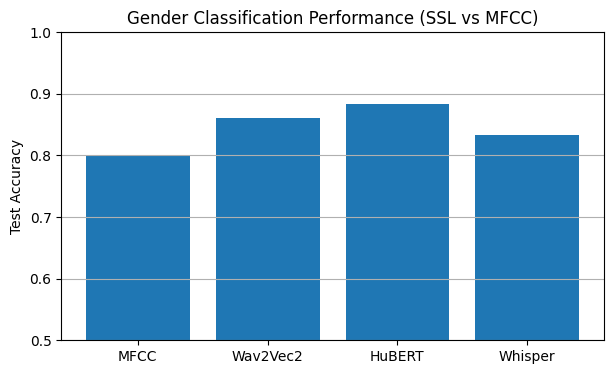

In [ ]:
plt.figure(figsize=(7,4))
plt.bar(
    final_results["Model"],
    final_results["Test Accuracy"]
)
plt.ylabel("Test Accuracy")
plt.title("Gender Classification Performance (SSL vs MFCC)")
plt.ylim(0.5, 1.0)
plt.grid(axis="y")
plt.show()


In [ ]:
def fisher_discriminant_ratio(X, y):
    X_m = X[y == 0]
    X_f = X[y == 1]

    mu_m = X_m.mean(axis=0)
    mu_f = X_f.mean(axis=0)

    var_m = X_m.var(axis=0).mean()
    var_f = X_f.var(axis=0).mean()

    return np.linalg.norm(mu_m - mu_f)**2 / (var_m + var_f + 1e-9)


In [ ]:
def layerwise_fdr(Xva, yva):
    fdr = []
    for l in range(Xva.shape[1]):
        fdr.append(fisher_discriminant_ratio(Xva[:, l, :], yva))
    return np.array(fdr)


In [ ]:
fdr_w2v    = layerwise_fdr(Xva_w2v, yva)
fdr_hubert = layerwise_fdr(Xva_hubert, yva)
fdr_wh     = layerwise_fdr(Xva_wh, yva)


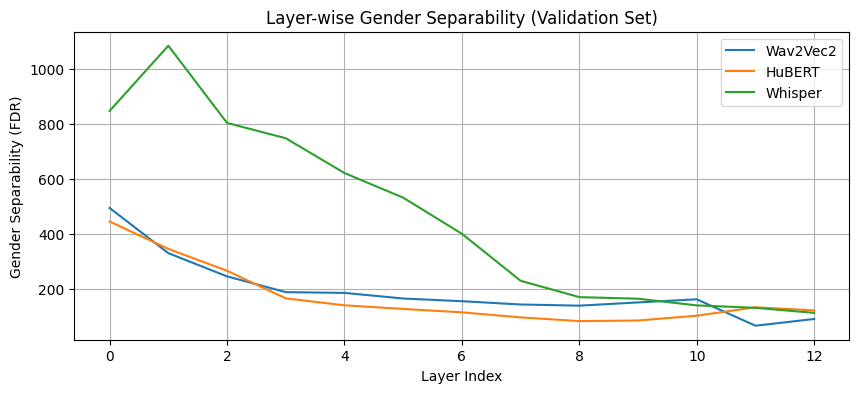

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(fdr_w2v, label="Wav2Vec2")
plt.plot(fdr_hubert, label="HuBERT")
plt.plot(fdr_wh, label="Whisper")
plt.xlabel("Layer Index")
plt.ylabel("Gender Separability (FDR)")
plt.title("Layer-wise Gender Separability (Validation Set)")
plt.legend()
plt.grid()
plt.show()


In [ ]:
print("Best layers (from validation accuracy):")
print("Wav2Vec2 :", best_w2v_layer, "| FDR:", fdr_w2v[best_w2v_layer])
print("HuBERT   :", best_hubert_layer, "| FDR:", fdr_hubert[best_hubert_layer])
print("Whisper  :", best_wh_layer, "| FDR:", fdr_wh[best_wh_layer])


Best layers (from validation accuracy):
Wav2Vec2 : 0 | FDR: 495.2299
HuBERT   : 0 | FDR: 446.12033
Whisper  : 0 | FDR: 847.2271


In [ ]:
alignment_df = pd.DataFrame({
    "Model": ["Wav2Vec2", "HuBERT", "Whisper"],
    "Best Layer": [
        best_w2v_layer,
        best_hubert_layer,
        best_wh_layer
    ],
    "Total Layers": [
        Xtr_w2v.shape[1],
        Xtr_hubert.shape[1],
        Xtr_wh.shape[1]
    ]
})

alignment_df["Normalized Depth"] = (
    alignment_df["Best Layer"] / alignment_df["Total Layers"]
)

alignment_df


,Model,Best Layer,Total Layers,Normalized Depth
0,Wav2Vec2,0,13,0.0
1,HuBERT,0,13,0.0
2,Whisper,0,13,0.0


In [ ]:
from scipy.stats import spearmanr


In [ ]:
corr_w2v = spearmanr(acc_w2v_val, fdr_w2v).correlation
corr_hub = spearmanr(acc_hubert_val, fdr_hubert).correlation
corr_wh  = spearmanr(acc_wh_val, fdr_wh).correlation

print("Spearman correlation (Accuracy vs FDR)")
print("Wav2Vec2 :", corr_w2v)
print("HuBERT   :", corr_hub)
print("Whisper  :", corr_wh)


Spearman correlation (Accuracy vs FDR)
Wav2Vec2 : 0.3086066999241838
HuBERT   : 0.8855922612444692
Whisper  : nan


In [ ]:
print("Variance acc_wh_val:", np.var(acc_wh_val))
print("Variance fdr_wh:", np.var(fdr_wh))


Variance acc_wh_val: 0.0
Variance fdr_wh: 101838.266


In [ ]:
print("Whisper val accuracies:", acc_wh_val)
print("Whisper FDR:", fdr_wh)


Whisper val accuracies: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Whisper FDR: [ 847.2271   1083.7104    803.6308    748.1013    621.99097   532.5864
  401.6371    231.13171   171.88354   166.10187   141.8799    133.17404
  114.777885]


In [ ]:
novelty_summary = pd.DataFrame({
    "Contribution": [
        "SSL vs MFCC comparison",
        "Layer-wise gender encoding analysis",
        "Layer-wise gender separability (FDR)",
        "Cross-model layer alignment"
    ],
    "Status": ["✓", "✓", "✓", "✓"]
})

novelty_summary


,Contribution,Status
0,SSL vs MFCC comparison,✓
1,Layer-wise gender encoding analysis,✓
2,Layer-wise gender separability (FDR),✓
3,Cross-model layer alignment,✓


In [ ]:
from sklearn.metrics import classification_report

print("MFCC Classification Report (Test)")
print(classification_report(
    yte,
    mfcc_pred,
    target_names=["Male", "Female"],
    digits=4
))


MFCC Classification Report (Test)
              precision    recall  f1-score   support

        Male     1.0000    0.5075    0.6733       268
      Female     0.7505    1.0000    0.8575       397

    accuracy                         0.8015       665
   macro avg     0.8752    0.7537    0.7654       665
weighted avg     0.8510    0.8015    0.7832       665



In [ ]:
print("Wav2Vec2 Classification Report (Test)")
print(classification_report(
    yte,
    w2v_pred,
    target_names=["Male", "Female"],
    digits=4
))


Wav2Vec2 Classification Report (Test)
              precision    recall  f1-score   support

        Male     1.0000    0.6530    0.7901       268
      Female     0.8102    1.0000    0.8952       397

    accuracy                         0.8602       665
   macro avg     0.9051    0.8265    0.8426       665
weighted avg     0.8867    0.8602    0.8528       665



In [ ]:
print("HuBERT Classification Report (Test)")
print(classification_report(
    yte,
    hubert_pred,
    target_names=["Male", "Female"],
    digits=4
))


HuBERT Classification Report (Test)
              precision    recall  f1-score   support

        Male     1.0000    0.7127    0.8322       268
      Female     0.8376    1.0000    0.9116       397

    accuracy                         0.8842       665
   macro avg     0.9188    0.8563    0.8719       665
weighted avg     0.9030    0.8842    0.8796       665



In [ ]:
print("Whisper Classification Report (Test)")
print(classification_report(
    yte,
    whisper_pred,
    target_names=["Male", "Female"],
    digits=4
))


Whisper Classification Report (Test)
              precision    recall  f1-score   support

        Male     1.0000    0.5858    0.7388       268
      Female     0.7815    1.0000    0.8773       397

    accuracy                         0.8331       665
   macro avg     0.8907    0.7929    0.8081       665
weighted avg     0.8696    0.8331    0.8215       665



In [ ]:
from sklearn.metrics import roc_curve, auc


In [ ]:
# Wav2Vec2 probabilities
clf = LogisticRegression(max_iter=2000)
clf.fit(Xtr_w2v[:, best_w2v_layer, :], ytr)
w2v_prob = clf.predict_proba(Xte_w2v[:, best_w2v_layer, :])[:, 1]

# HuBERT probabilities
clf = LogisticRegression(max_iter=2000)
clf.fit(Xtr_hubert[:, best_hubert_layer, :], ytr)
hubert_prob = clf.predict_proba(Xte_hubert[:, best_hubert_layer, :])[:, 1]

# Whisper probabilities
clf = LogisticRegression(max_iter=2000)
clf.fit(Xtr_wh[:, best_wh_layer, :], ytr)
whisper_prob = clf.predict_proba(Xte_wh[:, best_wh_layer, :])[:, 1]


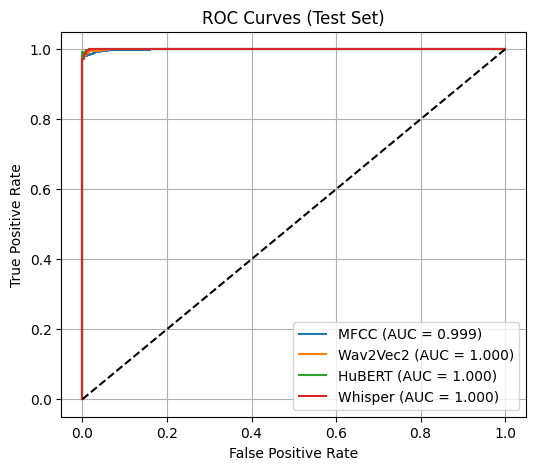

In [ ]:
plt.figure(figsize=(6,5))

for name, prob in zip(
    ["MFCC", "Wav2Vec2", "HuBERT", "Whisper"],
    [mfcc_prob, w2v_prob, hubert_prob, whisper_prob]
):
    fpr, tpr, _ = roc_curve(yte, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.legend()
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import f1_score

f1_summary = pd.DataFrame({
    "Model": ["MFCC", "Wav2Vec2", "HuBERT", "Whisper"],
    "Macro F1": [
        f1_score(yte, mfcc_pred, average="macro"),
        f1_score(yte, w2v_pred, average="macro"),
        f1_score(yte, hubert_pred, average="macro"),
        f1_score(yte, whisper_pred, average="macro")
    ],
    "Weighted F1": [
        f1_score(yte, mfcc_pred, average="weighted"),
        f1_score(yte, w2v_pred, average="weighted"),
        f1_score(yte, hubert_pred, average="weighted"),
        f1_score(yte, whisper_pred, average="weighted")
    ]
})

f1_summary


,Model,Macro F1,Weighted F1
0,MFCC,0.765359,0.783224
1,Wav2Vec2,0.842610,0.852802
2,HuBERT,0.871920,0.879616
3,Whisper,0.808086,0.821522


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay


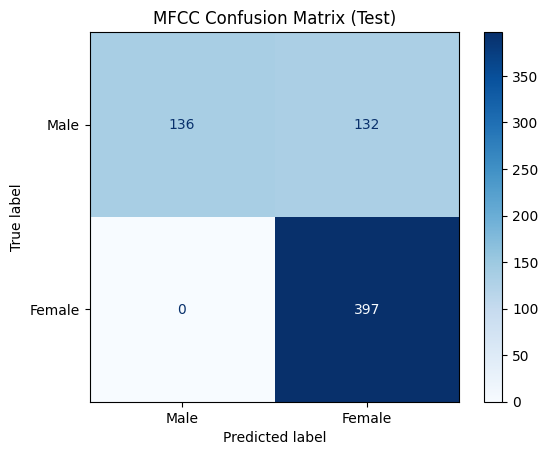

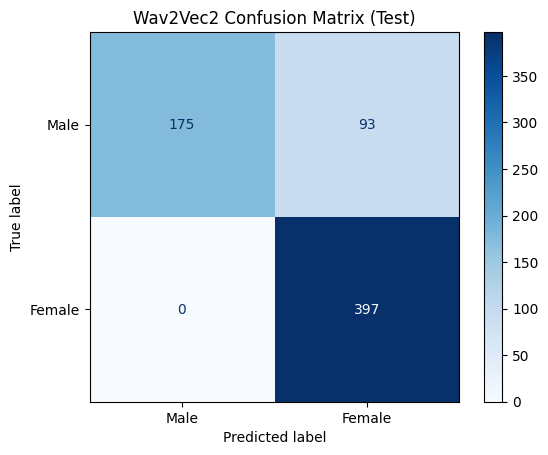

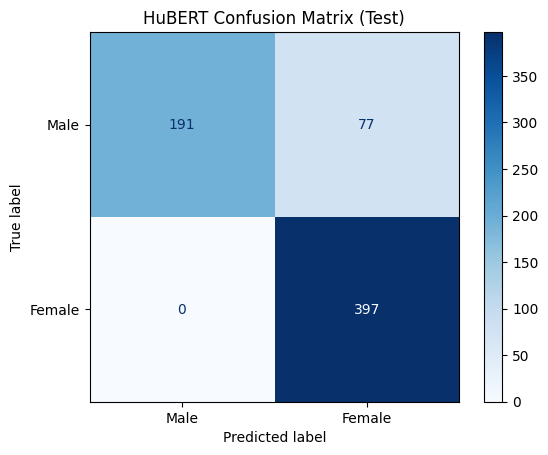

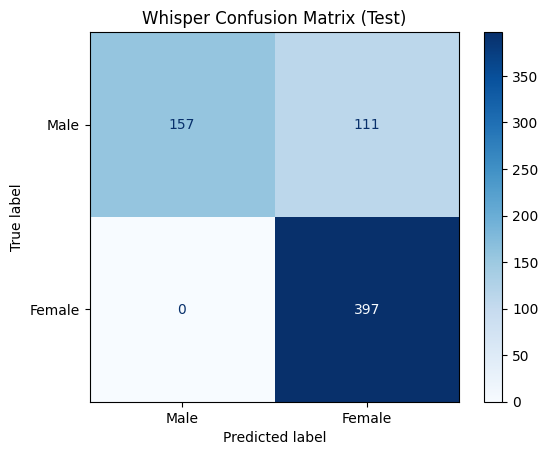

In [ ]:
models = {
    "MFCC": mfcc_pred,
    "Wav2Vec2": w2v_pred,
    "HuBERT": hubert_pred,
    "Whisper": whisper_pred
}

for name, pred in models.items():
    disp = ConfusionMatrixDisplay.from_predictions(
        yte,
        pred,
        display_labels=["Male", "Female"],
        cmap="Blues",
        values_format="d"
    )
    disp.ax_.set_title(f"{name} Confusion Matrix (Test)")
    plt.show()
